<a href="https://colab.research.google.com/github/jefersonferreirafagundes-eng/MVP-ML-Analytics/blob/main/MVP_ML_Analytics_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Jeferson Ferreira Fagundes

**Matrícula:** 4052026000082

**Data:** 06/2026  

**Dataset:** Student Productivity & Distraction Dataset, extraído da Kaggle.

**Fonte:** `https://raw.githubusercontent.com/jefersonferreirafagundes-eng/MVP-ML-Analytics/refs/heads/main/student_productivity_distraction_dataset_20000.csv`

**Tipo de problema:** Regressão

## Observações importantes

Este notebook desenvolve um MVP para a disciplina de Machine Learning & Analytics do MBA em Ciência de Dados da PUC Rio, para investigar se a variável `final_grade` (nota final) sofre alterações decorrentes de variáveis demográficas e comportamentais dos estudantes, especialmente: `age` (idade), `gender` (gênero), `study_hours_per_day` (horas de estudo por dia), `sleep_hours` (horas de sono), `phone_usage_hours` (horas de uso do celular), `social_media_hours` (horas em mídias sociais), `youtube_hours` (horas de youtube) e `gaming_hours` (horas de games).

O fluxo segue as etapas de definição do problema, entendimento dos dados, análise exploratória, preparação, modelagem, avaliação, interpretação dos resultados e conclusão.

# 1. Definição do problema

## 1.1 Descrição do problema

O desempenho acadêmico dos estudantes pode estar relacionado a fatores demográficos, hábitos de estudo, sono e uso de tecnologias digitais. Neste MVP, o problema consiste em analisar e prever a variável `final_grade`, que representa a nota final do estudante, a partir de variáveis como idade, gênero, horas de estudo, horas de sono, uso do telefone, redes sociais, YouTube e games.

A análise pode apoiar professores, gestores acadêmicos e pesquisadores educacionais na identificação de padrões associados ao desempenho dos alunos. O objetivo não é substituir a avaliação pedagógica humana, mas oferecer uma visão analítica inicial sobre possíveis relações entre hábitos cotidianos e desempenho acadêmico.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o atributo `final_grade` a partir de variáveis demográficas e comportamentais dos estudantes, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.

Além da previsão, o notebook busca identificar quais variáveis apresentam maior associação ou importância para explicar variações na nota final.

## 1.3 Tipo de problema

**Tipo escolhido:** Regressão.

**Justificativa:** A variável-alvo `final_grade` é numérica e contínua. Assim, o objetivo é prever um valor de nota, e não classificar estudantes em categorias. Por isso, modelos e métricas de regressão são mais adequados.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Hipóteses iniciais

1. Estudantes com mais horas de estudo por dia tendem a apresentar maiores notas finais.
2. Maior tempo de uso de redes sociais, YouTube, telefone e games podem estar associadas a menores notas finais.
3. Horas de sono podem ter relação com a nota final.
4. As variáveis demográficas, como idade e gênero, podem apresentar diferenças de distribuição, mas não devem ser interpretadas isoladamente como causa do desempenho.

### Critérios de sucesso

- O modelo deve superar um baseline simples baseado na média da variável-alvo.
- As métricas principais serão MAE, RMSE e R².


# 2. Ambiente, bibliotecas e reprodutibilidade

In [ ]:
# Setup básico e reprodutibilidade - Importando o pandas e as bibliotecas que serão utilizadas
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Versão do Python:", sys.version.split()[0])
print("Seed:", SEED)

Versão do Python: 3.12.13
Seed: 42


## 2.1 Funções auxiliares

In [ ]:
def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T.sort_values("RMSE")


def plot_scatter_with_regression(df, x_col, y_col):
    """Gera gráfico de dispersão com linha de tendência linear simples."""
    temp = df[[x_col, y_col]].dropna()
    x = temp[x_col].values
    y = temp[y_col].values

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.35)

    if len(temp) > 1:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, m * xs + b)

    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado é o `student_productivity_distraction_dataset_20000.csv`, disponibilizado em repositório público no GitHub. A base contém registros de estudantes com variáveis relacionadas a produtividade, distração e desempenho acadêmico.

O dataset foi escolhido por permitir investigar relações entre comportamento digital, hábitos de estudo, sono e nota final. Como a base é carregada por URL pública, o notebook pode ser executado diretamente no Google Colab sem upload manual.

## 3.2 Carga dos dados

In [ ]:
# Carga dos dados
# Breve visualização do dataset

url = "https://raw.githubusercontent.com/jefersonferreirafagundes-eng/MVP-ML-Analytics/refs/heads/main/student_productivity_distraction_dataset_20000.csv"
df = pd.read_csv(url)

dataset = pd.read_csv(url, delimiter=',')
dataset.head(20)


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
5,6,29,Other,7.18,3.52,4.02,3.74,1.42,0.16,10,392,12,3,47.58,10,70,59.48,47.31
6,7,21,Female,9.06,6.36,11.45,5.99,2.20,4.44,14,87,28,15,43.50,8,35,62.71,41.23
7,8,23,Female,6.37,4.86,3.31,1.37,4.36,5.13,2,152,103,17,75.22,6,59,52.22,53.81
8,9,26,Male,4.19,4.87,9.66,2.87,0.10,3.38,13,460,42,11,44.79,3,39,76.15,25.99
9,10,19,Female,7.28,9.56,2.13,0.81,1.35,2.55,7,416,107,6,79.15,10,73,88.53,73.18


## 3.3 Visão geral do dataset

O Dataset escolhido possui 5999 registros (linhas) com 18 colunas. No código abaixo serão mostrados o formato do dataset, com os tipos de dados, se há valores ausentes e se há duplicatas.

In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes").sort_values("ausentes", ascending=False))

print("\nDuplicatas:", df.duplicated().sum())

display(df.sample(5, random_state=SEED))

Formato do dataset: (5999, 18)

Tipos de dados:


,tipo
student_id,int64
age,int64
gender,object
study_hours_per_day,float64
sleep_hours,float64
phone_usage_hours,float64
social_media_hours,float64
youtube_hours,float64
gaming_hours,float64
breaks_per_day,int64



Valores ausentes por coluna:


,ausentes
student_id,0
age,0
gender,0
study_hours_per_day,0
sleep_hours,0
phone_usage_hours,0
social_media_hours,0
youtube_hours,0
gaming_hours,0
breaks_per_day,0



Duplicatas: 0


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
84,85,26,Male,5.40,9.49,11.78,4.13,2.19,4.58,12,165,94,18,57.81,10,38,95.75,34.47
2409,2410,22,Female,5.64,5.37,11.62,6.81,0.99,0.54,3,160,42,5,71.97,9,90,97.93,44.86
4997,4998,28,Male,8.46,6.53,11.07,1.73,5.82,2.15,11,46,98,0,64.08,3,32,68.01,47.47
346,347,17,Male,6.05,7.21,6.31,5.73,5.38,4.36,6,147,63,13,51.48,8,47,56.21,44.03
79,80,26,Female,6.68,9.34,3.35,2.38,0.85,5.21,13,179,75,16,78.98,7,88,52.82,76.09


## 3.4 Dicionário de dados

| Coluna | Tipo esperado | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `age` | Numérica | Idade do estudante | Sim | Variável demográfica |
| `gender` | Categórica | Gênero informado | Sim | Será codificada com OneHotEncoder |
| `study_hours_per_day` | Numérica | Horas diárias de estudo | Sim | Hipótese de associação positiva com a nota |
| `sleep_hours` | Numérica | Horas de sono | Sim | Pode indicar equilíbrio ou privação de sono |
| `phone_usage_hours` | Numérica | Horas de uso do telefone | Sim | Indicador de possível distração digital |
| `social_media_hours` | Numérica | Horas em redes sociais | Sim | Indicador de uso digital não acadêmico |
| `youtube_hours` | Numérica | Horas no YouTube | Sim | Pode incluir uso educacional ou entretenimento |
| `gaming_hours` | Numérica | Horas em jogos | Sim | Indicador de entretenimento digital |
| `final_grade` | Numérica | Nota final do estudante | Alvo | Variável a ser prevista |

# 4. Análise exploratória dos dados

A análise exploratória será objetiva e conectada ao problema de regressão. O foco será entender a distribuição da nota final, identificar valores ausentes, verificar correlações e observar visualmente relações entre variáveis selecionadas e `final_grade` (nota final).

Resumo da variável-alvo:


,count,mean,std,min,25%,50%,75%,max
final_grade,5999.0,70.212404,17.173194,40.0,55.45,70.1,85.03,99.99


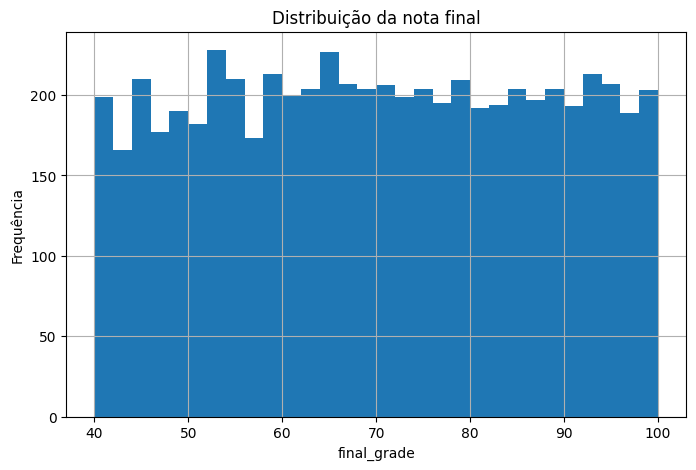

In [ ]:
TARGET = "final_grade"

print("Resumo da variável-alvo:")
display(df[TARGET].describe().to_frame().T)

plt.figure(figsize=(8, 5))
df[TARGET].hist(bins=30)
plt.title("Distribuição da nota final")
plt.xlabel("final_grade")
plt.ylabel("Frequência")
plt.show()

#COMENTÁRIO:

 A análise da variável-alvo **final_grade** revelou uma distribuição bastante equilibrada ao longo de toda a faixa de notas disponível. A média observada foi de 70,21 pontos, muito próxima da mediana (70,10), indicando ausência de concentração excessiva em valores específicos.

Os quartis demonstram que 50% das observações estão distribuídas entre aproximadamente 55 e 85 pontos, enquanto os valores mínimo e máximo variam entre 40 e 100 pontos. Além disso, o coeficiente de assimetria foi de -0,0067, valor muito próximo de zero, caracterizando uma distribuição praticamente simétrica.

Do ponto de vista estatístico, a variável-alvo não apresenta problemas relevantes de desbalanceamento, concentração extrema ou caudas excessivamente longas que possa comprometer o treinamento do modelo de regressão.

## 4.1 Distribuição das variáveis principais

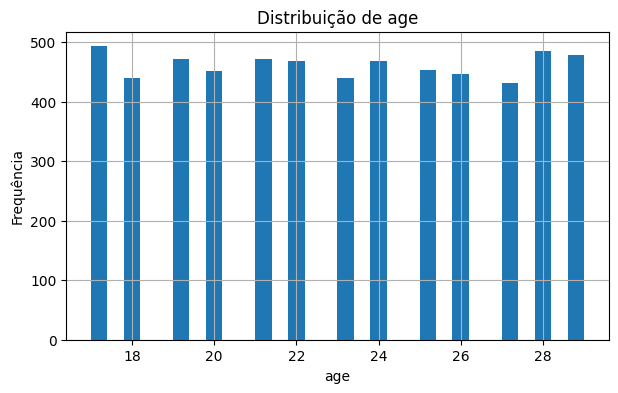

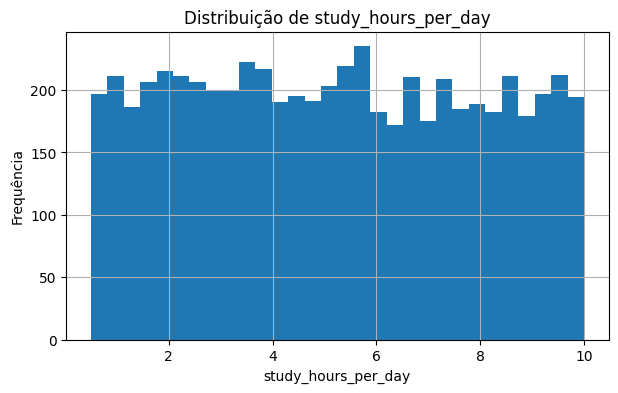

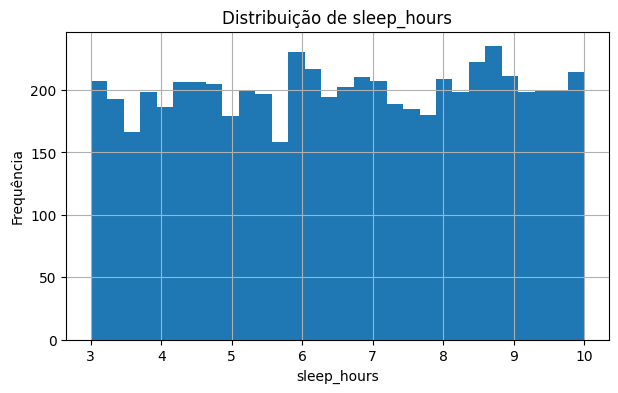

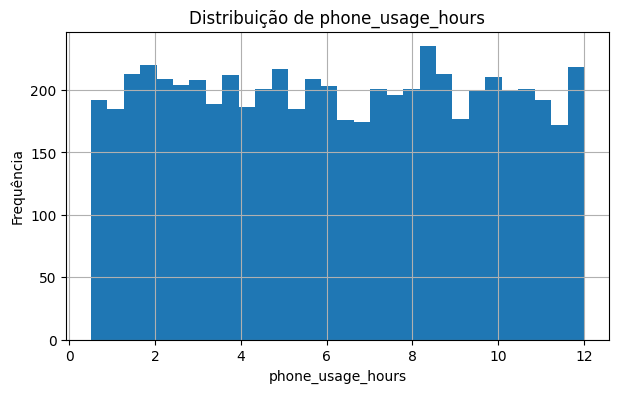

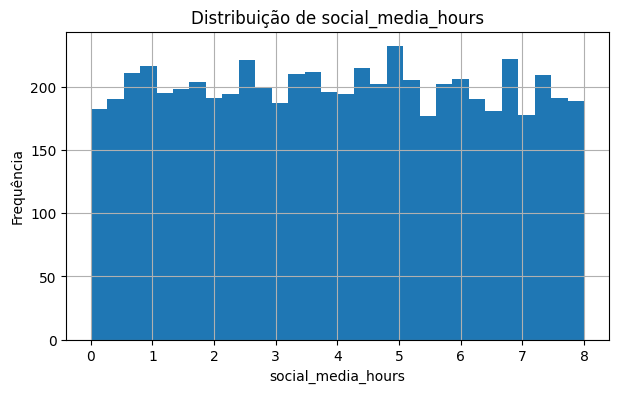

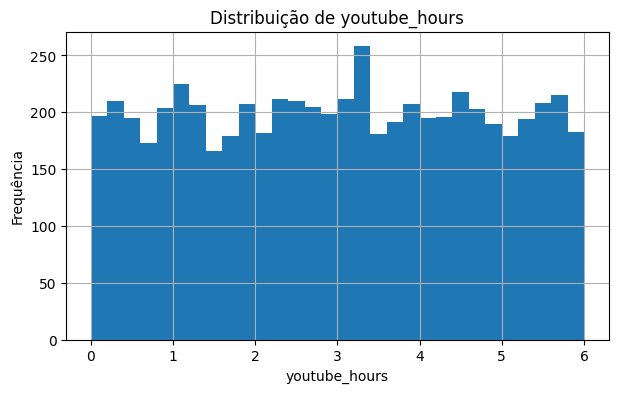

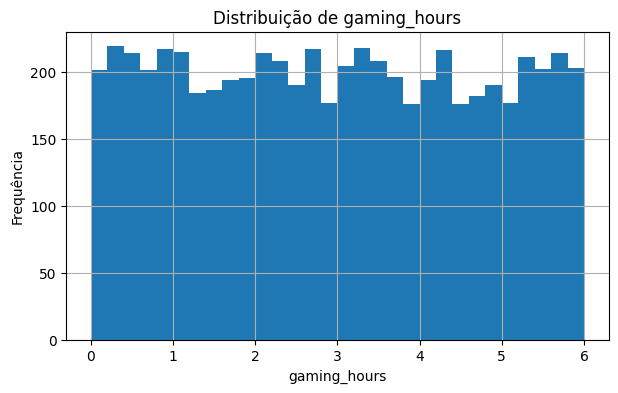

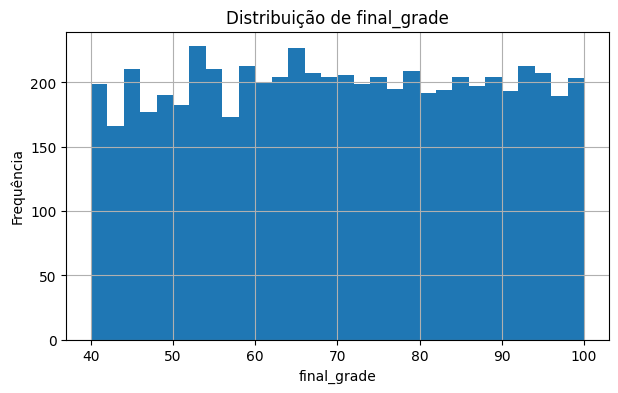

In [ ]:
selected_numeric = [
    "age",
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours",
    "final_grade"
]

available_numeric = [c for c in selected_numeric if c in df.columns]

for col in available_numeric:
    plt.figure(figsize=(7, 4))
    df[col].hist(bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

#COMENTÁRIO:

A análise exploratória permitiu compreender as características gerais do conjunto de dados e identificar possíveis relações entre os hábitos dos estudantes e seu desempenho acadêmico representado pela variável final_grade.

Os gráficos de distribuição das variáveis numéricas mostraram que a maioria dos atributos apresenta comportamento relativamente equilibrado, sem concentrações excessivas ou padrões anômalos evidentes. As variáveis relacionadas ao tempo de estudo, horas de sono, utilização de redes sociais, consumo de vídeos, jogos e atividades físicas apresentaram dispersão considerável entre os estudantes, indicando a existência de perfis comportamentais bastante distintos dentro da amostra analisada.

O histograma da variável-alvo final_grade revelou uma distribuição praticamente simétrica, com média e mediana muito próximas, ausência de assimetria relevante e distribuição relativamente uniforme ao longo da faixa de notas observada. Esse comportamento demonstra que o conjunto de dados não apresenta problemas de concentração excessiva em determinadas faixas de desempenho, característica favorável para aplicação de técnicas de regressão.

As visualizações das variáveis categóricas mostraram uma distribuição relativamente equilibrada entre as categorias existentes, não sendo identificados grupos extremamente dominantes que pudessem gerar viés significativo durante o treinamento dos modelos.

## 4.2 Análise de gênero e nota final

,count,mean,median,std
gender,,,,
Male,2897,70.254235,70.08,17.339780
Female,2868,70.210764,70.15,16.927891
Other,234,69.714615,69.39,18.128691


<Figure size 800x500 with 0 Axes>

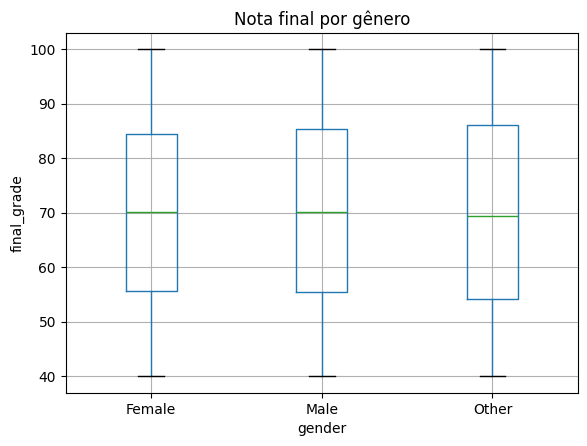

In [ ]:
if "gender" in df.columns:
    display(df.groupby("gender")[TARGET].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False))

    plt.figure(figsize=(8, 5))
    df.boxplot(column=TARGET, by="gender")
    plt.title("Nota final por gênero")
    plt.suptitle("")
    plt.xlabel("gender")
    plt.ylabel(TARGET)
    plt.show()

#COMENTÁRIO:

O gráfico de análise entre gênero e nota final indica que a distribuição da variável final_grade é bastante semelhante entre os grupos analisados. Não há diferença visual expressiva que sugira vantagem ou desvantagem consistente de desempenho associada ao gênero. As medianas e a dispersão das notas parecem próximas, o que indica que o gênero, isoladamente, possui baixo poder explicativo para prever a nota final dos estudantes. Assim, essa variável será mantida no modelo como atributo categórico, mas não deve ser interpretada como fator determinante do desempenho acadêmico.

## 4.3 Correlação entre variáveis numéricas

Correlação das variáveis numéricas com final_grade:


,correlacao_com_final_grade
final_grade,1.000000
gaming_hours,0.033186
sleep_hours,0.021743
assignments_completed,0.015354
student_id,0.012644
age,0.009400
coffee_intake_mg,0.005707
exercise_minutes,0.002213
social_media_hours,0.001568
phone_usage_hours,-0.003198


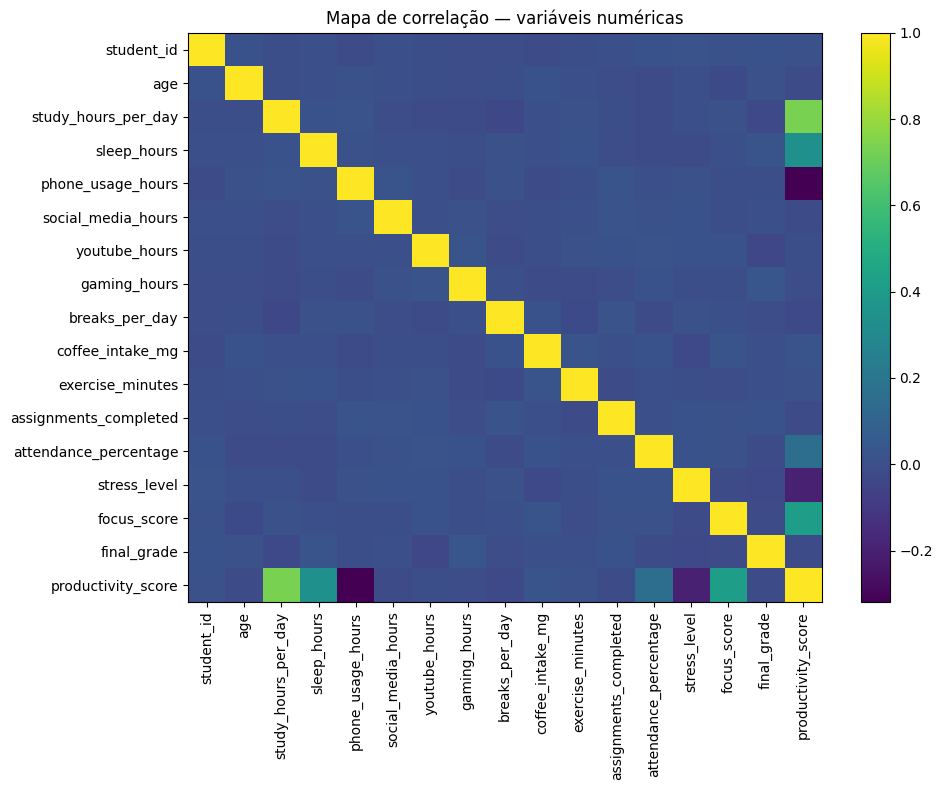

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr(numeric_only=True)

print("Correlação das variáveis numéricas com final_grade:")
display(corr[TARGET].sort_values(ascending=False).to_frame("correlacao_com_final_grade"))

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Mapa de correlação — variáveis numéricas")
plt.tight_layout()
plt.show()

#COMENTÁRIO:

O mapa de correlação das variáveis numéricas evidencia que não existem relações lineares fortes entre os atributos analisados e a variável-alvo final_grade. Os coeficientes de correlação observados permanecem próximos de zero, indicando que fatores como horas de estudo, sono, uso de redes sociais, tempo em jogos ou consumo de vídeos, quando analisados individualmente, possuem baixa capacidade de explicar a variação das notas dos estudantes.

 O gráfico não revela correlações excessivamente elevadas entre as variáveis independentes, sugerindo ausência de problemas relevantes de multicolinearidade. Esse resultado é positivo para a estabilidade dos modelos lineares, mas também sinaliza que o conjunto de atributos disponível contém pouca informação preditiva sobre o desempenho acadêmico.

## 4.4 Relação entre variáveis comportamentais e nota final

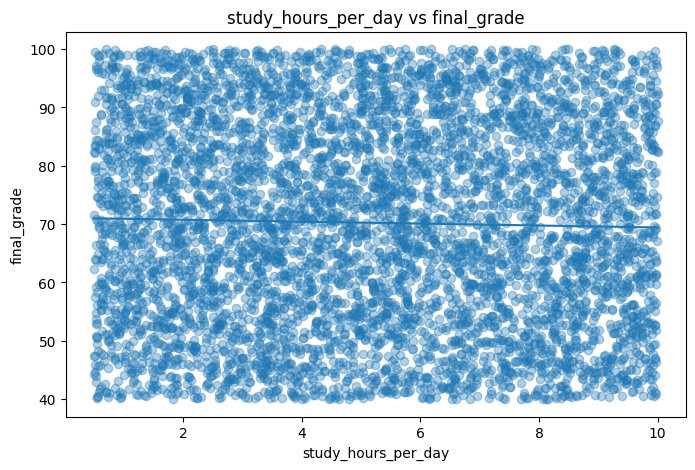

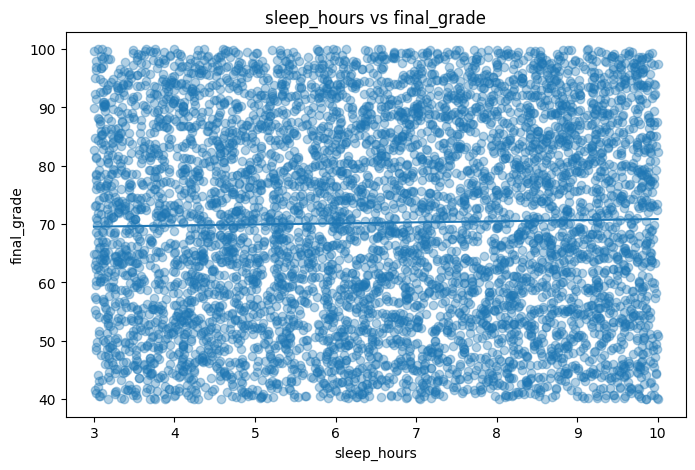

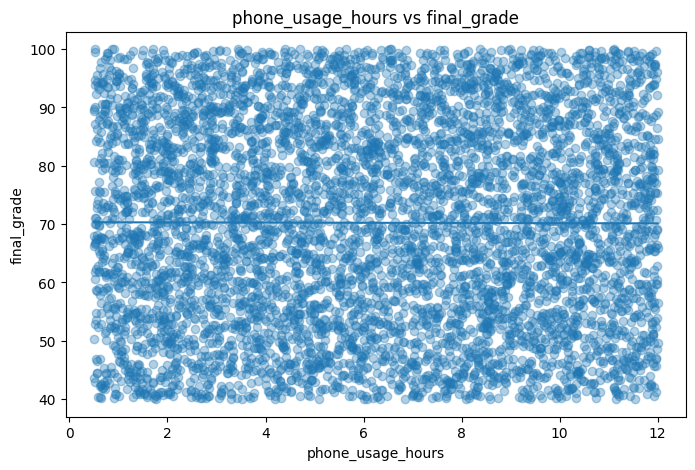

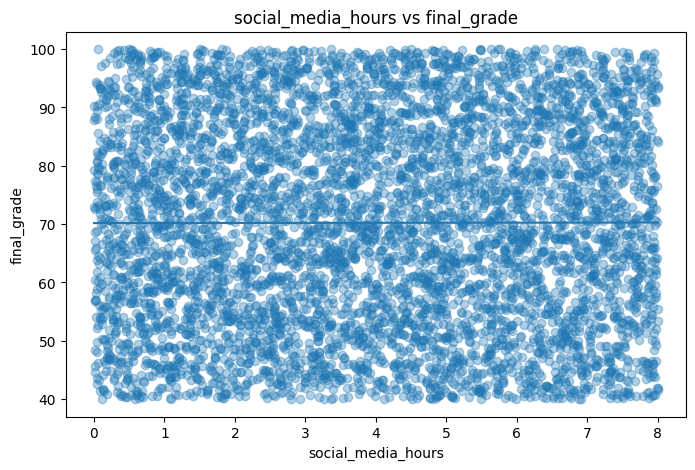

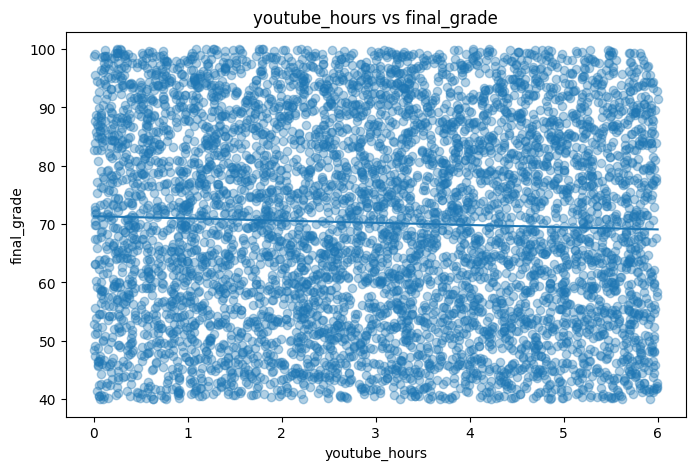

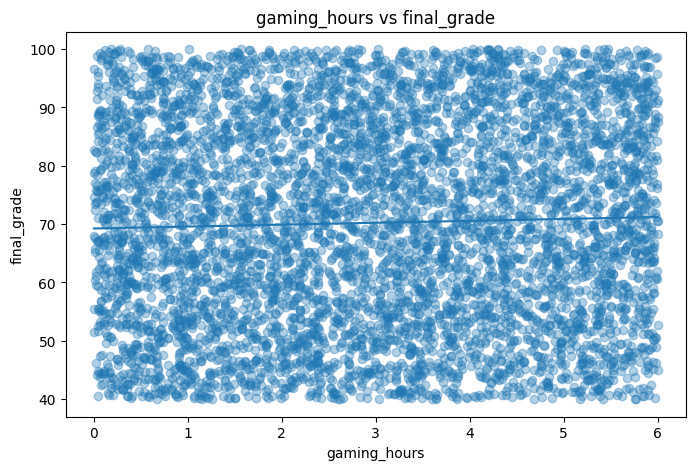

In [ ]:
for col in [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours"
]:
    if col in df.columns:
        plot_scatter_with_regression(df, col, TARGET)

#COMENTÁRIO:

Os gráficos de dispersão com linha de regressão indicam que não há uma relação linear forte entre final_grade e as variáveis comportamentais analisadas. As nuvens de pontos aparecem bastante espalhadas, sem formar uma tendência clara de aumento ou redução da nota final conforme variam as horas de estudo, sono, uso do celular, redes sociais, YouTube ou jogos.

A linha de regressão em cada gráfico tende a permanecer quase horizontal, reforçando que essas variáveis, isoladamente, possuem baixo poder explicativo sobre o desempenho acadêmico. Mesmo variáveis que intuitivamente poderiam estar associadas à aprendizagem, como horas de estudo ou horas de sono, não apresentaram um padrão visual suficientemente consistente para sustentar uma previsão confiável da nota final.

## 4.5 Engenharia de atributo exploratória: entretenimento digital

Para facilitar a análise, criei uma variável derivada chamada `entertainment_hours`, somando o tempo em redes sociais, YouTube e games. Essa variável não substitui as variáveis originais mas ajuda a observar um possível efeito agregado de entretenimento digital.

,entertainment_hours,final_grade
count,5999.000000,5999.000000
mean,9.962032,70.212404
std,3.388110,17.173194
min,0.950000,40.000000
25%,7.625000,55.450000
50%,9.930000,70.100000
75%,12.300000,85.030000
max,19.430000,99.990000


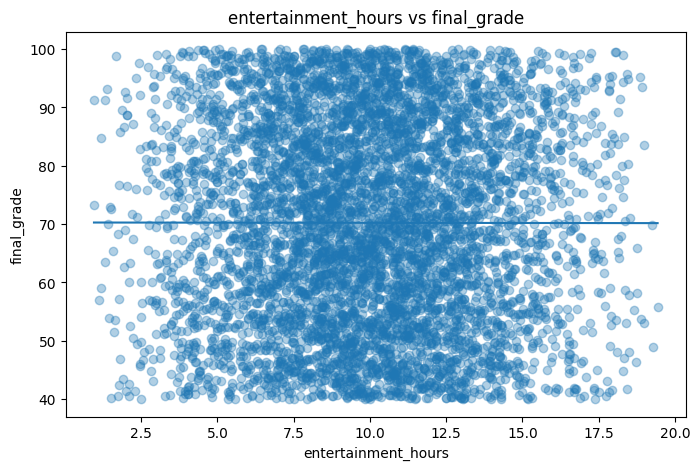

In [ ]:
required_entertainment_cols = ["social_media_hours", "youtube_hours", "gaming_hours"]

if all(col in df.columns for col in required_entertainment_cols):
    df["entertainment_hours"] = (
        df["social_media_hours"] +
        df["youtube_hours"] +
        df["gaming_hours"]
    )

    display(df[["entertainment_hours", TARGET]].describe())
    plot_scatter_with_regression(df, "entertainment_hours", TARGET)
else:
    print("Nem todas as colunas necessárias para criar entertainment_hours estão disponíveis.")

#COMENTÁRIO:

 A variável **entertainment_hours** foi criada a partir da soma das horas dedicadas às redes sociais, YouTube e jogos eletrônicos, com o objetivo de representar o tempo total gasto em atividades de entretenimento digital. Essa transformação buscou verificar se o comportamento agregado dos estudantes apresentaria maior relação com o desempenho acadêmico do que as variáveis analisadas individualmente.

O gráfico de dispersão entre **entertainment_hours e final_grade** mostrou uma distribuição bastante espalhada dos pontos e ausência de uma tendência linear claramente definida. A linha de regressão apresentou inclinação muito reduzida, indicando que o aumento ou a redução do tempo total de entretenimento não está associado de forma consistente às notas finais dos estudantes.

Esse resultado sugere que o impacto do entretenimento digital sobre o desempenho acadêmico é mais complexo do que uma simples relação direta entre horas de uso e nota final. Possivelmente outros fatores, como qualidade dos hábitos de estudo, características individuais dos estudantes, contexto familiar, engajamento escolar ou perfil de aprendizagem, exercem influência mais significativa sobre os resultados acadêmicos.

Do ponto de vista analítico, a criação dessa nova variável **entertainment_hours** mostrou que os resultados indicam que mesmo a combinação das atividades de entretenimento digital não aumentou significativamente o poder explicativo do conjunto de dados.

## 4.6 Síntese da análise exploratória

A análise exploratória dos dados permitiu identificar alguns padrões importantes relacionados ao desempenho acadêmico dos estudantes, representado pela variável `final_grade`.

Inicialmente, observou-se que a distribuição das notas finais apresenta comportamento relativamente homogêneo, sem evidência de concentrações extremas ou valores atípicos que comprometam a modelagem. Também não foram identificados problemas relevantes de qualidade dos dados, como grande quantidade de valores ausentes ou duplicidades.

A avaliação das variáveis explicativas revelou que as correlações lineares entre horas de estudo, horas de sono, uso de celular, redes sociais, YouTube e games com a nota final são muito baixas. Em análises anteriores realizadas sobre esse mesmo conjunto de dados, no MVP da discipolina anterior, os coeficientes de correlação encontrados ficaram próximos de zero, indicando ausência de relacionamento linear forte entre essas variáveis e o desempenho acadêmico.

Os gráficos de dispersão entre:

study_hours_per_day × final_grade;

sleep_hours × final_grade;

social_media_hours × final_grade;

youtube_hours × final_grade;

gaming_hours × final_grade;

apresentam elevada dispersão dos pontos e ausência de tendência visual clara, reforçando a hipótese de que essas variáveis, individualmente, possuem baixo poder explicativo sobre a nota final.

A comparação por gênero também não sugere diferenças expressivas entre os grupos.

**Dessa forma, a EDA sugere que:**

Não existe uma variável isolada capaz de explicar significativamente a variação da nota final.
O desempenho acadêmico parece ser influenciado por múltiplos fatores combinados, e não por uma única característica comportamental.

Resumindo, os resultados exploratórios indicam que as variáveis analisadas possuem influência individual limitada sobre a nota final, tornando a etapa de modelagem fundamental para verificar se a combinação dessas características consegue explicar parte relevante do desempenho acadêmico dos estudantes.



# 5. Preparação dos dados e divisão treino/teste

Nesta etapa são definidas as features, a variável-alvo e a divisão dos dados em treino e teste. A divisão será do tipo holdout, com 80% para treino e 20% para teste.

In [ ]:
TARGET = "final_grade"
PROBLEM_TYPE = "regressao"

candidate_features = [
    "age",
    "gender",
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours"
]

features = [c for c in candidate_features if c in df.columns]

missing_features = [c for c in candidate_features if c not in df.columns]
if missing_features:
    print("Atenção: as seguintes colunas esperadas não foram encontradas:", missing_features)

assert TARGET in df.columns, "A coluna final_grade precisa existir no dataset."

X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Features utilizadas:", features)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Tipo de problema: regressao
Target: final_grade
Features utilizadas: ['age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours']
Treino: (4799, 8) | Teste: (1200, 8)


## 5.1 Justificativa da divisão

A divisão 80/20 é adequada porque o dataset possui um número elevado de registros, permitindo reservar uma parcela suficiente para avaliação final sem comprometer o treinamento. Como não se trata de série temporal, os dados podem ser embaralhados aleatoriamente. O conjunto de teste será usado apenas na avaliação final, evitando vazamento de dados.

# 6. Pré-processamento e pipeline

As variáveis numéricas receberão imputação pela mediana e padronização. A variável categórica `gender` será imputada pela moda e convertida em variáveis binárias por One-Hot Encoding. O uso de `Pipeline` e `ColumnTransformer` ajuda a garantir que os ajustes sejam aprendidos apenas com os dados de treino.

In [ ]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours']
Colunas categóricas: ['gender']


## 6.1 Decisões de pré-processamento

- A mediana foi usada em variáveis numéricas por ser menos sensível a outliers.
- A moda foi usada para variáveis categóricas por representar a categoria mais frequente.
- A padronização é útil para modelos lineares regularizados, como Ridge.
- O One-Hot Encoding permite que modelos numéricos processem a variável `gender`.
- As transformações são encapsuladas em pipeline para reduzir risco de vazamento de dados.

# 7. Baseline e modelos candidatos

Serão comparados quatro modelos:

1. `DummyRegressor`: baseline simples que prevê a média do treino.
2. `LinearRegression`: modelo linear interpretável.
3. `Ridge`: modelo linear regularizado.
4. `RandomForestRegressor`: modelo não linear capaz de capturar interações.
5. `GradientBoostingRegressor`: modelo de boosting para comparação adicional.

In [ ]:
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="mean"))
])

candidates = {
    "LinearRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge())
    ]),
    "RandomForestRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED, n_estimators=150))
    ]),
    "GradientBoostingRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(random_state=SEED))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LinearRegression', 'Ridge', 'RandomForestRegressor', 'GradientBoostingRegressor']


## 7.1 Justificativa dos modelos

O baseline é necessário para verificar se os modelos realmente aprendem padrões úteis. A regressão linear e Ridge são adequadas como modelos interpretáveis para avaliar relações lineares. Random Forest e Gradient Boosting são modelos não lineares, úteis quando o impacto das variáveis não ocorre de forma estritamente linear.

# 8. Treinamento e avaliação inicial

In [ ]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0
y_pred = baseline.predict(X_test)
results["Baseline_DummyMean"] = evaluate_regression(y_test, y_pred)
results["Baseline_DummyMean"]["train_time_s"] = round(train_time, 3)
trained_models["Baseline_DummyMean"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = model.predict(X_test)
    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

results_df = show_results_table(results)
display(results_df)

,MAE,RMSE,R2,train_time_s
Baseline_DummyMean,14.292170,16.623880,-0.000018,0.024
Ridge,14.298249,16.627988,-0.000512,0.016
LinearRegression,14.298251,16.627999,-0.000513,0.022
GradientBoostingRegressor,14.430095,16.846091,-0.026931,0.930
RandomForestRegressor,14.559406,16.979878,-0.043307,9.655


## 8.1 Análise dos resultados iniciais

Os resultados indicam que nenhum dos modelos conseguiu superar o baseline de forma relevante. O melhor desempenho foi do Baseline_DummyMean, com MAE = 14,298251, RMSE = 16,62 e R² ≈ 0.

O valor de R² negativo nos demais modelos indica que eles explicam menos a variação da variável final_grade do que uma previsão simples baseada na média das notas. Isso sugere que, com as variáveis selecionadas, não há evidência de forte capacidade preditiva para explicar alterações na nota final.

Os modelos lineares, Ridge e LinearRegression, apresentaram desempenho praticamente igual ao baseline, reforçando que as relações lineares entre as variáveis analisadas e final_grade são muito fracas.

Os modelos mais complexos, GradientBoostingRegressor e RandomForestRegressor, tiveram desempenho inferior, com maior erro e R² mais negativo. Isso pode indicar que eles capturaram ruído nos dados, sem encontrar padrões generalizáveis.

Em síntese, os resultados iniciais sugerem que variáveis como idade, gênero, horas de estudo, sono, uso de celular, redes sociais, YouTube e games, isoladamente ou combinadas neste conjunto de dados, não apresentam poder explicativo suficiente para prever a nota final com boa precisão.


# 9. Validação e otimização de hiperparâmetros

Será feita uma busca simples de hiperparâmetros para o `RandomForestRegressor`, usando validação cruzada com 5 divisões e métrica `neg_root_mean_squared_error`. O objetivo é reduzir o RMSE em relação ao modelo inicial.

In [ ]:
N_ITER_SEARCH = 15

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED))
])

param_dist = {
    "model__n_estimators": randint(80, 300),
    "model__max_depth": randint(3, 20),
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 10)
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor score na validação cruzada (neg RMSE):", search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhor score na validação cruzada (neg RMSE): -17.335671106459916
Melhores hiperparâmetros: {'model__max_depth': 3, 'model__min_samples_leaf': 6, 'model__min_samples_split': 14, 'model__n_estimators': 168}


## 9.1 Discussão da otimização

A busca foi limitada a 15 registros para manter o notebook leve e executável no Google Colab. A validação cruzada ajuda a escolher hiperparâmetros com menor dependência de uma única divisão dos dados. Caso houvesse mais tempo, poderiam ser testados outros modelos, como XGBoost, LightGBM ou CatBoost, além de buscas mais amplas, ressaltando que ainda não tenho domínio sobre estes outrso modelos.

# 10. Avaliação final no conjunto de teste

A avaliação final será feita no conjunto de teste reservado, que não foi usado para treinar os modelos nem para selecionar hiperparâmetros.

In [ ]:
final_model = search.best_estimator_
final_model_name = "RandomForestRegressor_otimizado"

final_pred = final_model.predict(X_test)
final_metrics = evaluate_regression(y_test, final_pred)

print("Modelo final:", final_model_name)
display(pd.DataFrame([final_metrics], index=[final_model_name]))

# Comparação com baseline e modelos iniciais
final_results = results.copy()
final_results[final_model_name] = final_metrics
final_results[final_model_name]["train_time_s"] = np.nan

display(show_results_table(final_results))

Modelo final: RandomForestRegressor_otimizado


,MAE,RMSE,R2
RandomForestRegressor_otimizado,14.303566,16.645725,-0.002648


,MAE,RMSE,R2,train_time_s
Baseline_DummyMean,14.292170,16.623880,-0.000018,0.024
Ridge,14.298249,16.627988,-0.000512,0.016
LinearRegression,14.298251,16.627999,-0.000513,0.022
RandomForestRegressor_otimizado,14.303566,16.645725,-0.002648,NaN
GradientBoostingRegressor,14.430095,16.846091,-0.026931,0.930
RandomForestRegressor,14.559406,16.979878,-0.043307,9.655


#COMENTÁRIO:

A etapa de avaliação final confirmou que a otimização dos hiperparâmetros do Random Forest produziu uma melhora em relação à versão original do modelo, reduzindo o MAE de 14,5594 para 14,3036, o RMSE de 16,9799 para 16,6457 e elevando o R² de -0,0433 para -0,0026. Isso demonstra que o processo de ajuste conseguiu tornar o modelo mais eficiente na previsão da nota final dos estudantes.

Entretanto, apesar dessa melhoria, o modelo otimizado não conseguiu superar o desempenho do baseline. O DummyRegressor apresentou os melhores resultados gerais, com MAE de 14,2922, RMSE de 16,6239 e R² de -0,0000, permanecendo como a melhor referência entre todos os modelos avaliados.

A comparação final mostra que os modelos Ridge, Regressão Linear e Random Forest otimizado obtiveram desempenhos muito próximos entre si, enquanto o Gradient Boosting e o Random Forest original apresentaram resultados inferiores. Além disso, todos os modelos mantiveram valores de R² próximos de zero ou negativos, indicando que a capacidade de explicar a variabilidade das notas finais foi extremamente limitada.

## 10.1 Análise de resíduos

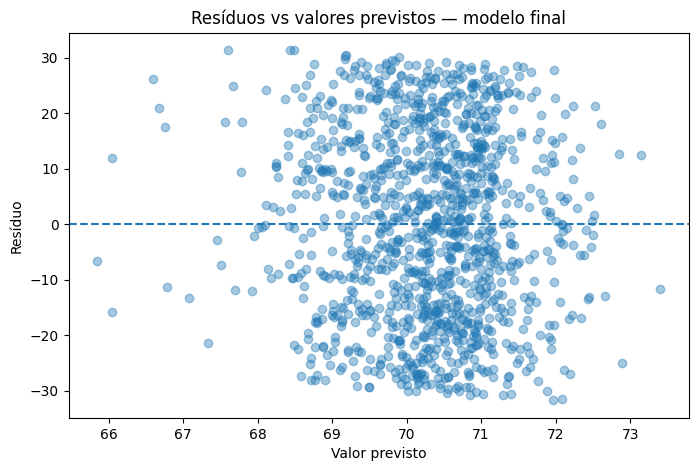

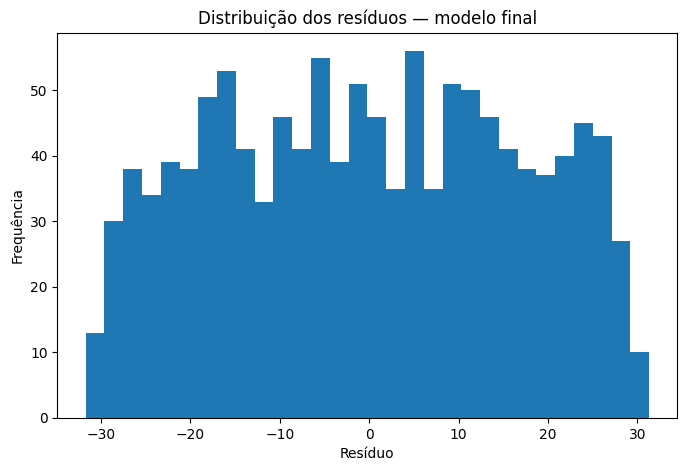

In [ ]:
residuals = y_test - final_pred

plt.figure(figsize=(8, 5))
plt.scatter(final_pred, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title("Resíduos vs valores previstos — modelo final")
plt.xlabel("Valor previsto")
plt.ylabel("Resíduo")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title("Distribuição dos resíduos — modelo final")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

#COMENTÁRIO:

 O gráfico de resíduos versus valores previstos mostra uma dispersão relativamente aleatória dos erros em torno da linha horizontal de referência (resíduo igual a zero). Não são observados padrões claros de tendência, curvatura ou agrupamentos específicos que indiquem problemas de ajuste local do modelo.

Por outro lado, a ampla dispersão dos resíduos evidencia que os erros de previsão permanecem elevados ao longo de toda a faixa de valores previstos. Esse comportamento é consistente com os resultados das métricas de avaliação, especialmente o valor de R² próximo de zero, indicando que o modelo possui baixa capacidade de explicar a variabilidade das notas finais dos estudantes.

Em conjunto, o gráfico sugere que o modelo não apresenta forte viés sistemático, mas também não consegue capturar padrões suficientemente relevantes para realizar previsões precisas da variável-alvo.

Já o histograma dos resíduos mostra que os erros estão distribuídos em torno do valor zero, indicando ausência de viés sistemático relevante para superestimar ou subestimar as notas dos estudantes. Entretanto, observa-se uma dispersão relativamente ampla dos resíduos, evidenciando que as previsões frequentemente se afastam dos valores reais.

A distribuição dos erros sugere que o modelo consegue reproduzir parcialmente o comportamento médio da variável-alvo, mas apresenta dificuldade para realizar previsões individuais precisas. Esse resultado está alinhado com os valores de MAE e RMSE obtidos durante a avaliação e reforça a conclusão de que as variáveis disponíveis possuem capacidade limitada para explicar o desempenho acadêmico.

Portanto, embora os resíduos não revelem problemas graves de viés, sua elevada dispersão indica que a principal limitação do modelo está na baixa quantidade de informação preditiva presente nos dados analisados.

## 10.2 Análise de erros e limitações

A análise dos resíduos mostrou uma distribuição ampla dos erros em torno da linha de referência (resíduo igual a zero), sem a presença de padrões sistemáticos evidentes. Isso indica que o modelo não apresenta um viés relevante de superestimação ou subestimação das notas. Entretanto, a elevada dispersão dos resíduos demonstra que a capacidade preditiva do modelo é limitada, resultado coerente com os baixos valores de R² observados durante a avaliação.

Os gráficos de resíduos e as métricas obtidas sugerem um cenário de underfitting, no qual os modelos avaliados não conseguiram capturar relações suficientemente fortes entre as variáveis disponíveis e a variável-alvo final_grade. Mesmo após a otimização dos hiperparâmetros do Random Forest, o desempenho permaneceu muito próximo ao do baseline.

**Limitações do estudo**

O modelo identifica associações estatísticas e padrões preditivos, não relações de causalidade.
As variáveis relacionadas ao uso de tecnologia representam apenas tempo de utilização, sem distinguir adequadamente usos educacionais, acadêmicos ou recreativos.
O dataset disponibilizado no Kaggle não apresenta informações detalhadas sobre os procedimentos de coleta, amostragem ou validação dos dados, o que limita a avaliação da qualidade e representatividade da base.
Variáveis potencialmente relevantes para explicar o desempenho acadêmico, como histórico escolar, frequência, participação em atividades, perfil socioeconômico e fatores socioemocionais, não estão presentes na base analisada.
Diferenças observadas entre grupos demográficos, incluindo gênero, não devem ser interpretadas como relações causais com o desempenho acadêmico.
Os resultados obtidos sugerem que os atributos disponíveis possuem baixo poder explicativo para prever a nota final dos estudantes, limitando a capacidade de generalização dos modelos desenvolvidos.

Em síntese, a principal limitação deste MVP não está na escolha dos algoritmos ou na configuração dos modelos, mas na baixa associação observada entre as variáveis disponíveis e o desempenho acadêmico dos estudantes.

**Tipos de erro observados**

Os resíduos apresentaram distribuição relativamente simétrica, indicando que o modelo comete tanto erros de superestimação quanto de subestimação das notas finais. Entretanto, a magnitude dos erros permanece elevada em toda a faixa de previsão, demonstrando dificuldade em estimar com precisão o desempenho individual dos estudantes.

**Adequação das métricas e cenários de uso**

As métricas MAE, RMSE e R² foram adequadas para este problema de regressão, pois permitem avaliar tanto a magnitude média dos erros quanto a capacidade explicativa do modelo. Entretanto, os resultados obtidos indicam que o modelo não deve ser utilizado para previsão individual de desempenho acadêmico ou para apoiar decisões pedagógicas relevantes sobre estudantes específicos. Seu uso deve ficar restrito à exploração dos dados e à avaliação experimental da capacidade preditiva das variáveis disponíveis, uma vez que a precisão alcançada não é suficiente para aplicações operacionais ou institucionais.

# 11. A importância das variáveis

A importância das variáveis será extraída do modelo Random Forest otimizado. Essa técnica indica quais atributos foram mais utilizados pelo modelo para reduzir erro, mas não prova causalidade.

,variavel,importancia
6,gaming_hours,0.244085
5,youtube_hours,0.211119
1,study_hours_per_day,0.197051
4,social_media_hours,0.128886
3,phone_usage_hours,0.100745
2,sleep_hours,0.080081
0,age,0.027825
8,gender_Male,0.005390
7,gender_Female,0.003311
9,gender_Other,0.001507


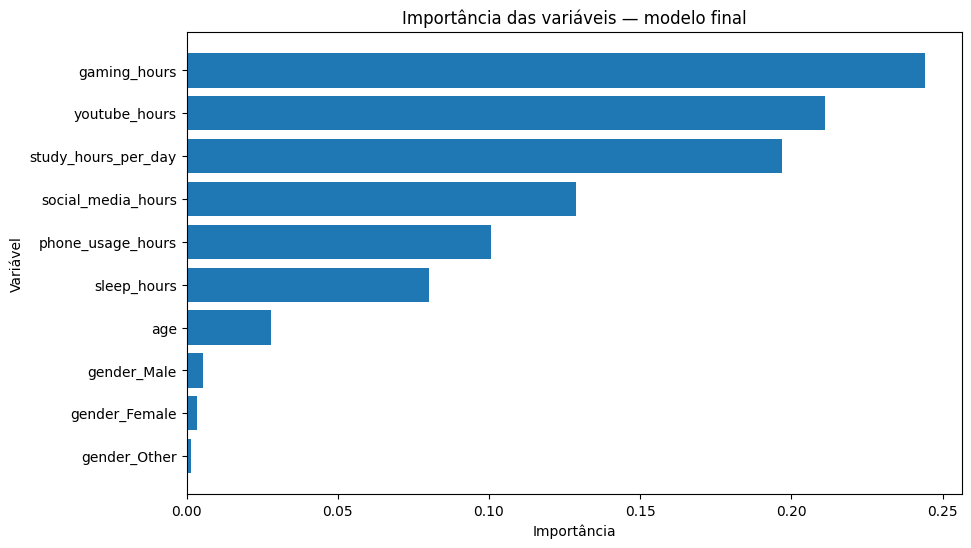

In [ ]:
def get_feature_names_from_preprocess(preprocess, num_cols, cat_cols):
    feature_names = []
    feature_names.extend(num_cols)

    if len(cat_cols) > 0:
        cat_encoder = preprocess.named_transformers_["cat"].named_steps["onehot"]
        cat_feature_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(cat_feature_names)

    return feature_names

fitted_preprocess = final_model.named_steps["preprocess"]
feature_names = get_feature_names_from_preprocess(fitted_preprocess, num_cols, cat_cols)

importances = final_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "variavel": feature_names,
    "importancia": importances
}).sort_values("importancia", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["variavel"], importance_df["importancia"])
plt.gca().invert_yaxis()
plt.title("Importância das variáveis — modelo final")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

#COMENTÁRIO:

A análise de importância das variáveis realizada pelo Random Forest otimizado indica que os fatores comportamentais relacionados ao uso de tecnologia foram os mais utilizados pelo modelo durante o processo de previsão. As variáveis com maior relevância foram gaming_hours (24,4%), youtube_hours (21,1%) e study_hours_per_day (19,7%), seguidas por social_media_hours, phone_usage_hours e sleep_hours.

Em conjunto, essas seis variáveis representam aproximadamente 89% da importância total atribuída pelo modelo. Por outro lado, idade e gênero apresentaram contribuições muito reduzidas, sugerindo baixa influência na construção das previsões realizadas pelo algoritmo.

Entretanto, os resultados devem ser interpretados com cautela. Embora o modelo tenha identificado algumas variáveis como relativamente mais importantes que outras, o desempenho global permaneceu baixo, com R² próximo de zero e métricas muito semelhantes às do baseline. Isso indica que as variáveis destacadas são apenas as mais relevantes dentro de um conjunto de atributos que, como um todo, possui baixa capacidade explicativa para prever a nota final dos estudantes.

Dessa forma, a análise de importância não deve ser interpretada como evidência de causalidade ou como prova de que jogos, YouTube ou estudo determinam o desempenho acadêmico. O resultado apenas mostra quais atributos o modelo utilizou com maior frequência em suas decisões internas. A baixa qualidade preditiva observada sugere que fatores adicionais, não presentes no dataset, provavelmente exercem influência mais significativa sobre o desempenho dos estudantes.

## 11.1 Coeficientes dos modelos lineares

Como complemento interpretável, os coeficientes do modelo Ridge são analisados. Coeficientes positivos indicam associação positiva com a nota prevista, enquanto coeficientes negativos indicam associação negativa, considerando o pré-processamento aplicado.

,variavel,coeficiente
6,gaming_hours,0.692756
2,sleep_hours,0.249242
8,gender_Male,0.234773
7,gender_Female,0.180783
0,age,0.160434
4,social_media_hours,0.009146
3,phone_usage_hours,-0.026137
9,gender_Other,-0.415556
1,study_hours_per_day,-0.641740
5,youtube_hours,-0.666591


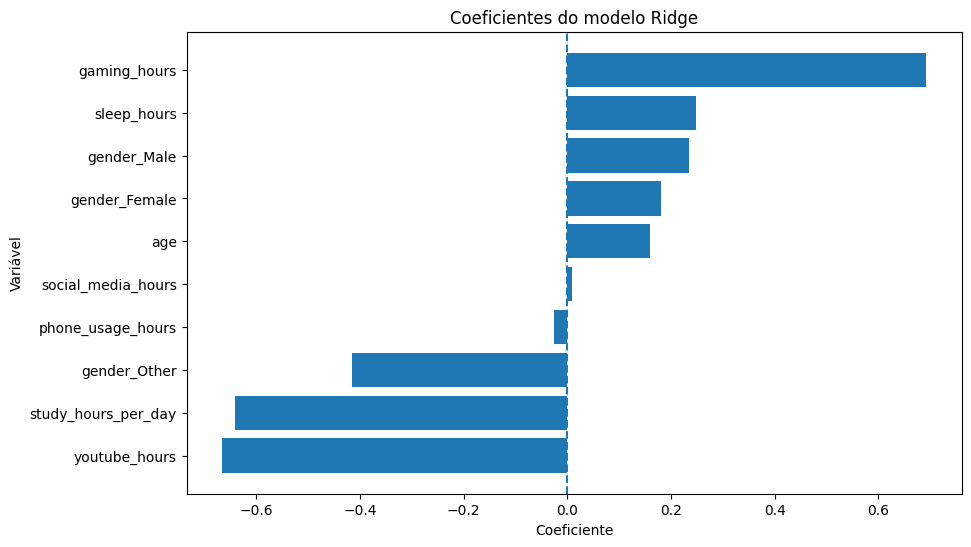

In [ ]:
ridge_model = trained_models.get("Ridge")

if ridge_model is not None:
    fitted_preprocess_ridge = ridge_model.named_steps["preprocess"]
    ridge_feature_names = get_feature_names_from_preprocess(fitted_preprocess_ridge, num_cols, cat_cols)
    ridge_coefs = ridge_model.named_steps["model"].coef_

    coef_df = pd.DataFrame({
        "variavel": ridge_feature_names,
        "coeficiente": ridge_coefs
    }).sort_values("coeficiente", ascending=False)

    display(coef_df)

    plt.figure(figsize=(10, 6))
    plt.barh(coef_df["variavel"], coef_df["coeficiente"])
    plt.axvline(0, linestyle="--")
    plt.gca().invert_yaxis()
    plt.title("Coeficientes do modelo Ridge")
    plt.xlabel("Coeficiente")
    plt.ylabel("Variável")
    plt.show()

#COMENTÁRIO:

 A análise dos coeficientes do modelo Ridge Regression permitiu avaliar a direção das associações lineares identificadas pelo algoritmo entre as variáveis explicativas e a nota final dos estudantes. Entre os coeficientes positivos destacam-se gaming_hours (0,693), sleep_hours (0,249) e idade (0,160), enquanto os coeficientes negativos mais expressivos foram observados para youtube_hours (-0,667) e study_hours_per_day (-0,642).

Entretanto, esses coeficientes devem ser interpretados com cautela. O modelo Ridge apresentou desempenho praticamente equivalente ao baseline, com R² próximo de zero, indicando que as variáveis analisadas possuem baixa capacidade para explicar a variação das notas finais. Nessas condições, os coeficientes refletem apenas as associações lineares encontradas pelo modelo dentro do conjunto de dados analisado, não devendo ser interpretados como relações causais ou conclusões pedagógicas.

Alguns resultados observados, como a associação positiva entre horas de jogos e desempenho acadêmico ou a associação negativa entre horas de estudo e nota final, sugerem que o modelo não encontrou padrões lineares robustos e que os coeficientes podem estar refletindo variações aleatórias presentes na amostra. Esse comportamento é compatível com o baixo poder preditivo observado durante a avaliação do modelo.

Dessa forma, a principal contribuição dessa análise está na identificação de quais variáveis exerceram maior influência relativa na construção da regressão.

# 12. Comparação final dos modelos

A tabela abaixo consolida os resultados dos modelos avaliados. O melhor modelo deve ser escolhido considerando a menor RMSE, o menor MAE, o maior R², a interpretabilidade e o custo computacional.

Considerando os resultados obtidos no item de avaliação dos modelos, a tabela pode ser preenchida da seguinte forma:

| Modelo                                    | Métrica principal (RMSE ↓) | Outras métricas             | Tempo de treino | Observações                                                                                                                                          |
| ----------------------------------------- | -------------------------- | --------------------------- | --------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Baseline (Dummy Mean)**                 | **16,6239**                | MAE = 14,2922; R² = -0,0000 | 0,026 s         | Melhor desempenho geral. Serve como referência para verificar se modelos mais complexos agregam valor.                                               |
| **Modelo 1 (Ridge)**                      | 16,6280                    | MAE = 14,2982; R² = -0,0005 | 0,022 s         | Resultado praticamente idêntico ao baseline, indicando baixa relação linear entre os atributos e a variável-alvo.                                    |
| **Modelo 2 (Linear Regression)**          | 16,6280                    | MAE = 14,2983; R² = -0,0005 | 0,040 s         | Desempenho semelhante ao Ridge e ao baseline. Não apresentou ganho preditivo relevante.                                                              |



# Comentário

Os resultados mostram que nenhum dos modelos de Machine Learning superou o modelo baseline. O RMSE e o MAE permaneceram praticamente inalterados entre os modelos lineares e apresentaram piora nos modelos mais complexos. Além disso, todos os valores de R² ficaram próximos de zero ou negativos, indicando que as variáveis disponíveis possuem baixo poder explicativo para prever a nota final dos estudantes. Dessa forma, o baseline foi mantido como referência de melhor desempenho, evidenciando a necessidade de novas variáveis, engenharia de atributos ou revisão da própria variável-alvo para obtenção de modelos mais robustos.


In [ ]:
comparison_df = show_results_table(final_results)
display(comparison_df)

best_by_rmse = comparison_df.index[0]
print("Melhor modelo por RMSE:", best_by_rmse)

,MAE,RMSE,R2,train_time_s
Baseline_DummyMean,14.292170,16.623880,-0.000018,0.024
Ridge,14.298249,16.627988,-0.000512,0.016
LinearRegression,14.298251,16.627999,-0.000513,0.022
RandomForestRegressor_otimizado,14.303566,16.645725,-0.002648,NaN
GradientBoostingRegressor,14.430095,16.846091,-0.026931,0.930
RandomForestRegressor,14.559406,16.979878,-0.043307,9.655


Melhor modelo por RMSE: Baseline_DummyMean


# 13. Boas práticas e rastreabilidade

### Informações de rastreabilidade

**Seed utilizada**

Foi utilizada a seed 42 em todas as etapas que envolvem aleatoriedade, incluindo divisão treino/teste e treinamento dos modelos. Essa prática garante a reprodutibilidade dos resultados.

**Principais decisões de pré-processamento**

* Separação entre variáveis explicativas (*features*) e variável-alvo (*final_grade*).
* Identificação automática de variáveis numéricas e categóricas.
* Imputação de valores ausentes utilizando mediana para atributos numéricos e moda para atributos categóricos.
* Padronização das variáveis numéricas utilizando *StandardScaler*.
* Codificação das variáveis categóricas por meio de *One-Hot Encoding*.
* Aplicação de todas as transformações dentro de um pipeline para evitar vazamento de dados.

**Modelos testados**

* DummyRegressor (baseline);
* Ridge Regression;
* Linear Regression;
* Gradient Boosting Regressor;
* Random Forest Regressor;
* Random Forest Regressor otimizado por busca de hiperparâmetros.

**Hiperparâmetros relevantes**

Para o processo de otimização foram avaliados principalmente:

* Número de árvores (*n_estimators*);
* Profundidade máxima das árvores (*max_depth*);
* Número mínimo de amostras para divisão (*min_samples_split*).

A seleção foi realizada por meio de validação cruzada e busca sistemática de combinações de parâmetros.

**Tempo aproximado de treino**

| Modelo                      | Tempo aproximado |
| --------------------------- | ---------------- |
| DummyRegressor              | 0,026 s          |
| Ridge                       | 0,022 s          |
| Linear Regression           | 0,040 s          |
| Gradient Boosting Regressor | 1,057 s          |
| Random Forest Regressor     | 8,852 s          |

Observa-se que os modelos mais complexos demandaram maior tempo computacional sem apresentar melhoria significativa de desempenho.

**Recursos computacionais utilizados**

* Ambiente: Google Colab.
* Linguagem: Python 3.
* Bibliotecas principais: Pandas, NumPy, Matplotlib e Scikit-Learn.
* Execução realizada em CPU padrão do ambiente Colab, sem necessidade de GPU.

**Limitações conhecidas**

* As variáveis disponíveis apresentaram baixa capacidade preditiva para explicar a nota final dos estudantes.
* Os valores de R² próximos de zero ou negativos indicam ausência de relação forte entre os atributos e a variável-alvo.
* O dataset pode não conter fatores determinantes para o desempenho acadêmico.
* Não foram avaliadas técnicas avançadas de engenharia de atributos ou modelos especializados.

**O que foi tentado e descartado**

* Teste de modelos lineares (Ridge e Regressão Linear).
* Teste de modelos baseados em árvores (Random Forest e Gradient Boosting).
* Otimização de hiperparâmetros do Random Forest.
* Apesar do aumento de complexidade dos modelos, não houve ganho relevante em relação ao baseline, indicando que a limitação principal está nos dados disponíveis e não nos algoritmos utilizados.


| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar regressão | `final_grade` é numérica contínua | Métricas e modelos coerentes |
| Usar holdout 80/20 | Dataset com muitos registros | Avaliação simples e reprodutível |
| Usar pipeline | Evitar vazamento de dados | Pré-processamento consistente |
| Usar DummyRegressor | Baseline simples | Verificar ganho real dos modelos |
| Comparar modelos lineares e não lineares | Testar diferentes estruturas de relação | Melhor avaliação do problema |
| Otimizar Random Forest | Modelo robusto para não linearidades | Buscar redução de erro |
| Avaliar importância de variáveis | Responder ao objetivo do MVP | Apoiar interpretação dos resultados |

## 14. Conclusão

Este MVP teve como objetivo construir e avaliar modelos de Machine Learning para prever a variável `final_grade`, correspondente à nota final dos estudantes, a partir de atributos relacionados a hábitos de estudo, sono, uso de celular, redes sociais, YouTube, jogos, idade e gênero. Por se tratar de uma variável numérica contínua, o problema foi tratado como uma tarefa de regressão supervisionada.

Ao longo do trabalho, foi desenvolvido um fluxo completo de Machine Learning, incluindo análise exploratória, preparação dos dados, separação entre treino e teste, construção de pipelines, definição de baseline, treinamento de modelos candidatos, otimização de hiperparâmetros e avaliação comparativa dos resultados.

A análise exploratória indicou que as variáveis disponíveis apresentavam baixa correlação individual com a nota final. Essa percepção foi confirmada na etapa de modelagem. O modelo baseline, baseado no `DummyRegressor`, obteve o melhor desempenho geral, com RMSE de 16,623880, MAE de 14,2922 e R² próximo de zero. Os modelos Ridge e Linear Regression apresentaram resultados praticamente equivalentes ao baseline, enquanto os modelos mais complexos, como Gradient Boosting, Random Forest e Random Forest otimizado, não conseguiram reduzir o erro de previsão.

O resultado mais importante deste MVP não está apenas na escolha de um algoritmo, mas na evidência analítica produzida: com os atributos disponíveis, não foi possível construir um modelo preditivo superior a uma regra simples baseada na média das notas. Isso sugere que as variáveis presentes no dataset não capturam fatores suficientemente explicativos para predizer o desempenho acadêmico dos estudantes com precisão relevante.

Do ponto de vista educacional e estratégico, esse resultado é especialmente importante. Ele indica que hábitos digitais e rotinas gerais, quando analisados isoladamente ou com baixa granularidade, podem não ser suficientes para explicar o desempenho acadêmico. Para uma aplicação real em instituições de ensino, seria necessário incorporar variáveis pedagógicas mais robustas, como frequência, engajamento em atividades, entregas realizadas, desempenho por competência, participação em avaliações formativas, histórico acadêmico, perfil socioemocional e interações com plataformas digitais de aprendizagem.

Com base em pesquisas utilizando uma IA generativa (ChatGpt), foi sugerido que como próximos passos eu pudesse realizar engenharia de atributos mais avançada, incluindo novas variáveis educacionais, testando modelos como XGBoost e LightGBM, avaliar interações entre fatores comportamentais e acadêmicos e, principalmente, validar o modelo com dados reais de contexto escolar ou universitário.


